# Задание 1. Работа с данными (ID_data_mass_18122012)


In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


file_path = "ID_data_mass_18122012.xlsx"
sheet_name = "VU"


In [94]:
HEADER_ROW = 1
df_raw2 = pd.read_excel(file_path, sheet_name=sheet_name, header=HEADER_ROW)


df = df_raw2.copy()
df.columns = df.columns.map(lambda c: str(c).strip())

print("Список колонок после выбора заголовка:")
print(list(df.columns))

Список колонок после выбора заголовка:
['Unnamed: 0', 'Unnamed: 1', 'Глубина манометра', 'Dшт', 'Руст', 'Рзаб', 'Pлин', 'Руст.1', 'Рзаб.1', 'Рлин', 'Туст', 'Тна шлейфе', 'Тзаб', 'Tлин', 'Дебит газа', 'Дебит ст. конд.', 'Дебит воды', 'Дебит смеси', 'Дебит гааз', 'Дебит кон нестабильный', 'Дебит воды.1', 'Нэф', 'Рпл. Тек (послед точка на КВД)', 'Рпл. Тек (Расчет по КВД)', 'Рпл. Тек (Карноухов)', 'Pсб', 'Pсб.1', 'Ro_g', 'Ro_c', 'Ro_w', 'Удельная плотность газа', 'G_total', 'КГФ', 'КГФ.1']


/home/andrew/ITMO/Основы ML/.venv/lib64/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


In [95]:

df = df.replace([" ", "", "-", "NA", "N/A"], np.nan)

TARGET_G_TOTAL = "G_total"
TARGET_KGF = "КГФ"


In [96]:
target_cols = [TARGET_G_TOTAL, TARGET_KGF]
df = df[~df[target_cols].isna().all(axis=1)].reset_index(drop=True)
feature_names = [c for c in df.columns if c not in target_cols]
print(df.shape, len(feature_names))

(24, 34) 32


In [97]:
def nan_quantile(x: np.ndarray, q: float) -> float:
    """Квантиль с учётом NaN (игнорируя пропуски), без использования готовых функций."""
    x_clean = x[~np.isnan(x)]
    if x_clean.size == 0:
        return np.nan
    x_sorted = np.sort(x_clean)
    pos = q * (len(x_sorted) - 1)
    lower = int(np.floor(pos))
    upper = int(np.ceil(pos))
    if lower == upper:
        return x_sorted[lower]
    return x_sorted[lower] + (x_sorted[upper] - x_sorted[lower]) * (pos - lower)


def descriptive_stats(x: np.ndarray) -> dict:
    """Базовые элементы описательной статистики для одномерного массива."""
    x_clean = x[~np.isnan(x)]
    if x_clean.size == 0:
        return {
            "count": 0,
            "mean": np.nan,
            "std": np.nan,
            "min": np.nan,
            "q1": np.nan,
            "median": np.nan,
            "q3": np.nan,
            "max": np.nan,
        }
    mean = x_clean.mean()
    std = x_clean.std(ddof=1) if x_clean.size > 1 else 0.0
    return {
        "count": x_clean.size,
        "mean": mean,
        "std": std,
        "min": x_clean.min(),
        "q1": nan_quantile(x_clean, 0.25),
        "median": nan_quantile(x_clean, 0.5),
        "q3": nan_quantile(x_clean, 0.75),
        "max": x_clean.max(),
    }


def pairwise_corr(x: np.ndarray, y: np.ndarray) -> float:
    """Парная корреляция Пирсона с игнорированием пар с NaN."""
    mask = (~np.isnan(x)) & (~np.isnan(y))
    x_clean = x[mask]
    y_clean = y[mask]
    n = x_clean.size
    if n < 2:
        return np.nan
    x_mean = x_clean.mean()
    y_mean = y_clean.mean()
    num = np.sum((x_clean - x_mean) * (y_clean - y_mean))
    den = np.sqrt(np.sum((x_clean - x_mean) ** 2) * np.sum((y_clean - y_mean) ** 2))
    if den == 0:
        return np.nan
    return num / den


def corr_matrix(df_num: pd.DataFrame) -> pd.DataFrame:
    """Матрица попарных корреляций для числового датафрейма df_num."""
    cols = df_num.columns
    m = len(cols)
    corr = np.zeros((m, m), dtype=float)
    for i in range(m):
        for j in range(m):
            corr[i, j] = pairwise_corr(df_num[cols[i]].values, df_num[cols[j]].values)
    return pd.DataFrame(corr, index=cols, columns=cols)

In [98]:
def entropy_from_counts(counts: np.ndarray) -> float:
    total = counts.sum()
    if total == 0:
        return 0.0
    p = counts / total
    p = p[p > 0]
    return -np.sum(p * np.log2(p))


def entropy(values: np.ndarray) -> float:
    """Энтропия дискретной случайной величины (значения могут быть числами или строками)."""
    vals, counts = np.unique(values, return_counts=True)
    return entropy_from_counts(counts)


def information_gain(feature: np.ndarray, target: np.ndarray) -> float:
    """Information gain(target | feature) для дискретного признака и таргета."""
    mask = (~pd.isna(feature)) & (~pd.isna(target))
    f = feature[mask]
    t = target[mask]
    if f.size == 0:
        return 0.0

    h_y = entropy(t)
    vals, counts = np.unique(f, return_counts=True)
    total = f.size

    cond_entropy = 0.0
    for v, c in zip(vals, counts):
        mask_v = (f == v)
        t_v = t[mask_v]
        cond_entropy += (c / total) * entropy(t_v)

    return h_y - cond_entropy


def split_info(feature: np.ndarray) -> float:
    mask = ~pd.isna(feature)
    f = feature[mask]
    if f.size == 0:
        return 0.0
    vals, counts = np.unique(f, return_counts=True)
    return entropy_from_counts(counts)


def gain_ratio(feature: np.ndarray, target: np.ndarray) -> float:
    ig = information_gain(feature, target)
    si = split_info(feature)
    if si == 0:
        return 0.0
    return ig / si


def discretize_into_bins(x: np.ndarray, n_bins: int = 4) -> np.ndarray:
    """Дискретизация непрерывного признака по квантилям в n_bins бинов.
    NaN сохраняются как NaN.
    """
    x_clean = x.copy()
    mask = ~np.isnan(x_clean)
    if mask.sum() == 0:
        return x_clean

    percentiles = np.linspace(0, 100, n_bins + 1)
    bin_edges = np.percentile(x_clean[mask], percentiles)
    # легкий сдвиг, чтобы избежать совпадения границ
    bin_edges[0] -= 1e-9
    bin_edges[-1] += 1e-9

    x_disc = x_clean.copy()
    x_disc[mask] = np.digitize(x_clean[mask], bin_edges)
    return x_disc


def make_discrete_for_gain_ratio(series: pd.Series, n_bins: int = 4) -> np.ndarray:
    """Приводим серию к числам (единицы измерения типа 'кг/с' -> NaN), потом бинним."""
    x = pd.to_numeric(series, errors="coerce").values
    return discretize_into_bins(x, n_bins=n_bins)

In [103]:
numeric_cols = [c for c in df.columns if c not in target_cols]


stats_dict = {}
for col in numeric_cols:
    x = pd.to_numeric(df[col], errors="coerce").values
    stats_dict[col] = descriptive_stats(x)

stats_df = pd.DataFrame(stats_dict).T
display(stats_df)

,count,mean,std,min,q1,median,q3,max
Unnamed: 0,23.0,15364.130435,8844.412866,804.000000,10653.500000,20503.000000,20503.000000,20503.000000
Unnamed: 1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Глубина манометра,22.0,3631.127273,34.389356,3576.300000,3594.725000,3650.000000,3653.000000,3653.000000
Dшт,23.0,11.804348,2.569128,7.940000,9.530000,11.110000,14.290000,15.880000
Руст,23.0,242.507904,59.287573,138.866667,195.550000,249.600000,291.663710,337.108108
Рзаб,22.0,367.727273,67.399316,239.300000,316.025000,379.400000,422.075000,458.600000
Pлин,23.0,98.861344,12.094472,73.306638,94.416770,101.300000,107.309079,121.682930
Руст.1,23.0,240.673913,59.242876,136.000000,194.500000,249.000000,293.000000,333.000000
Рзаб.1,22.0,359.990909,70.700824,239.300000,292.825000,374.100000,422.050000,458.500000
Рлин,23.0,98.286720,12.396412,72.579258,90.945790,100.600000,106.480000,123.616800


### Гистограммы распределения для каждого числового признака
с линиями первого (Q1) и третьего (Q3) квартилей

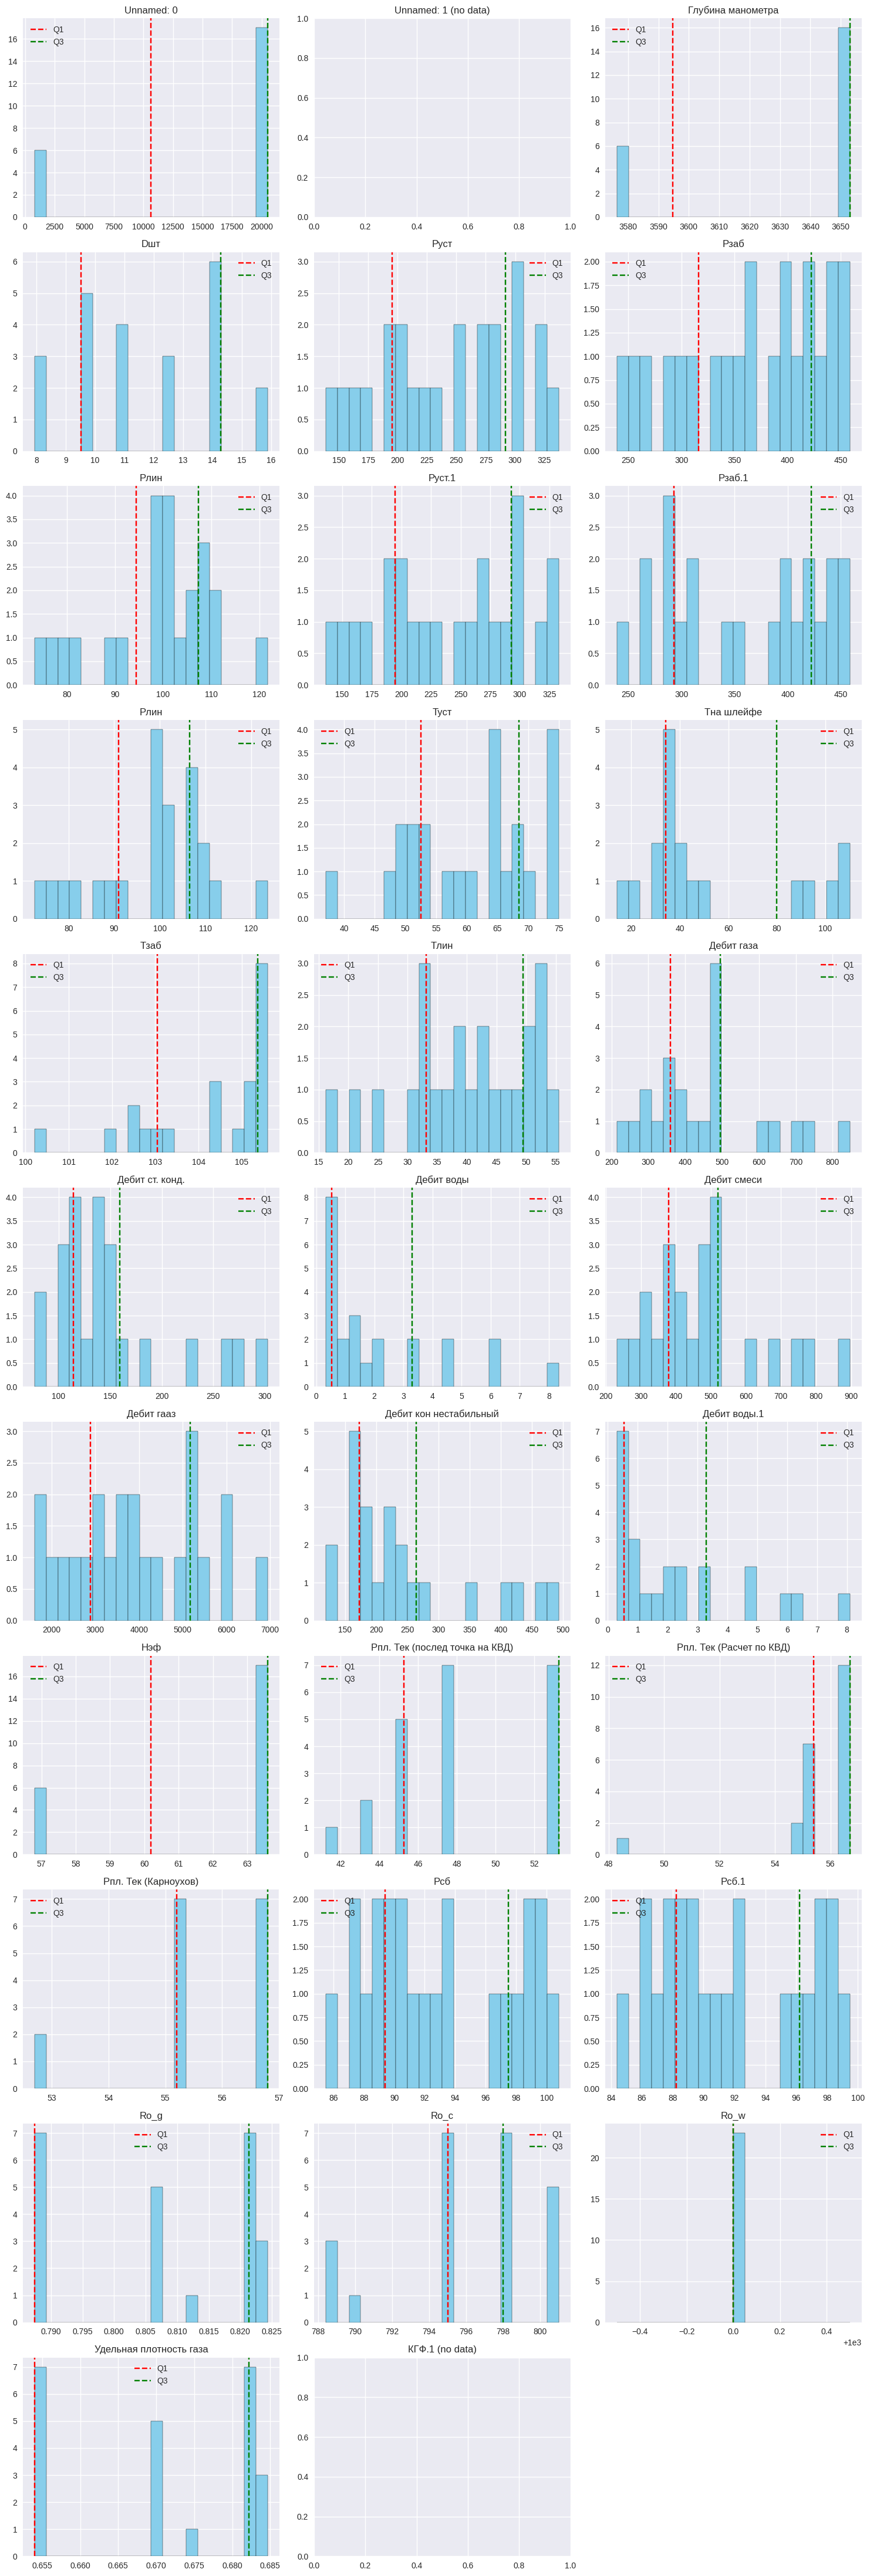

In [ ]:
import math
numeric_cols = [c for c in df.columns if c not in target_cols]

n = len(numeric_cols)
if n == 0:
    print("Нет признаков для построения гистограмм.")
else:
    n_cols = 3
    n_rows = math.ceil(n / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.ravel()

    for i, col in enumerate(numeric_cols):
        ax = axes[i]
        x = pd.to_numeric(df[col], errors="coerce").values
        x_clean = x[~np.isnan(x)]
        if x_clean.size == 0:
            ax.set_title(col + " (no data)")
            continue

        q1 = nan_quantile(x_clean, 0.25)
        q3 = nan_quantile(x_clean, 0.75)

        ax.hist(x_clean, bins=20, color="skyblue", edgecolor="black")
        ax.axvline(q1, color="red", linestyle="--", label="Q1")
        ax.axvline(q3, color="green", linestyle="--", label="Q3")
        ax.set_title(col)
        ax.legend()

    # Удаляем лишние оси, если их больше, чем признаков
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

### Комментарий к гистограммам распределений

- Большинство технологических параметров (давления, дебиты, температуры) имеют асимметричные распределения (например, дебиты ограничены снизу нулём и имеют «правый хвост»).
- Для дебитов (`Дебит газа`, `Дебит смеси`, `Дебит ст. конд.`, `Дебит гааз`, `Дебит кон нестабильный`) видно несколько значений существенно выше Q3, что соответствует высокодебитным режимам и рассматривается как реальные наблюдения, а не ошибки.
- Для параметров типа `Тзаб`, `Ro_c`, `Удельная плотность газа`, `Ro_w` разброс очень небольшой, распределения сосредоточены около одной точки → это либо почти константы, либо слабо меняющиеся параметры.
- Признаки с полностью пустыми гистограммами (`Unnamed: 1`, `КГФ.1`) подтверждают, что данных в них нет и их можно безопасно удалить из анализа.

### Матрица корреляций (по модулю) и тепловая карта

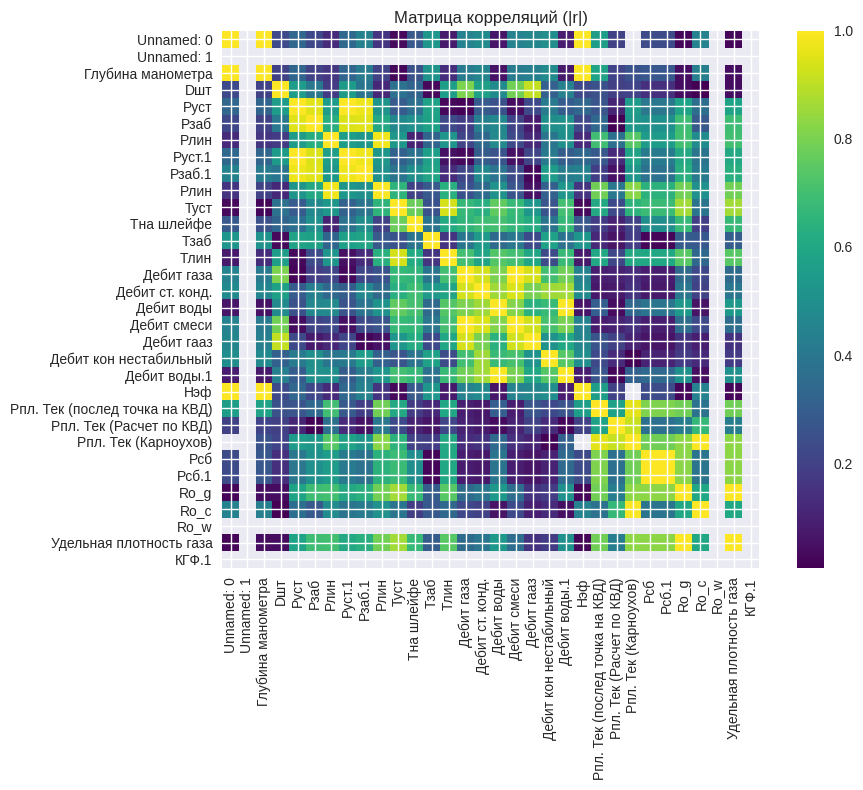

In [ ]:
numeric_cols = [c for c in df.columns if c not in target_cols]

if not numeric_cols:
    print("Нет признаков для расчёта корреляций.")
else:
    df_num = pd.DataFrame({
        c: pd.to_numeric(df[c], errors="coerce") for c in numeric_cols
    })

    corr_df = corr_matrix(df_num)
    corr_abs = corr_df.abs()

    fig, ax = plt.subplots(figsize=(10, 8))
    cax = ax.imshow(corr_abs.values, cmap="viridis")
    ax.set_xticks(range(len(corr_abs.columns)))
    ax.set_yticks(range(len(corr_abs.index)))
    ax.set_xticklabels(corr_abs.columns, rotation=90)
    ax.set_yticklabels(corr_abs.index)
    fig.colorbar(cax)
    plt.title("Матрица корреляций (|r|)")
    plt.tight_layout()
    plt.show()

### Комментарий к матрице корреляций

- На тепловой карте видны **ясные блоки высоких корреляций** между группами признаков: давлением на устье/забое (`Руст`, `Рзаб`, `Pсб` и их варианты с `.1`), дебитами (`Дебит газа`, `Дебит смеси`, `Дебит ст. конд.`, `Дебит гааз`), а также различными оценками пластового давления (`Рпл. Тек (...)`).
- Для целевых переменных `G_total` и `КГФ` хорошо коррелируют соответствующие им физические параметры: дебиты и давления (для `G_total`) и пластовые давления/забойные давления (для `КГФ`).
- Сильно скоррелированные между собой признаки рассматриваются как **кандидаты на укрупнение**: из каждой группы можно оставить по одному/двум представителям, чтобы уменьшить мультиколлинеарность и избежать дублирования информации.
- Признаки, не демонстрирующие заметной корреляции ни с целями, ни с другими важными параметрами, попадают в кандидаты на исключение как слабо информативные.

### Важность признаков по gain_ratio относительно G_total и КГФ

gain_G_series:
 Дебит газа                        1.000000
Дебит смеси                       1.000000
Дебит ст. конд.                   0.618548
Туст                              0.610607
Дебит кон нестабильный            0.533583
Рпл. Тек (Карноухов)              0.510094
Tлин                              0.482072
Дебит гааз                        0.454947
Dшт                               0.440575
Глубина манометра                 0.411200
Дебит воды.1                      0.337193
Ro_c                              0.335804
Ro_g                              0.330528
Удельная плотность газа           0.330528
Тна шлейфе                        0.328280
Рзаб                              0.327904
Рпл. Тек (послед точка на КВД)    0.325420
Рпл. Тек (Расчет по КВД)          0.325420
Рзаб.1                            0.299522
Рлин                              0.289170
dtype: float64

gain_K_series:
 Рпл. Тек (Карноухов)              0.505694
Рзаб.1                            0.427395
Dшт   

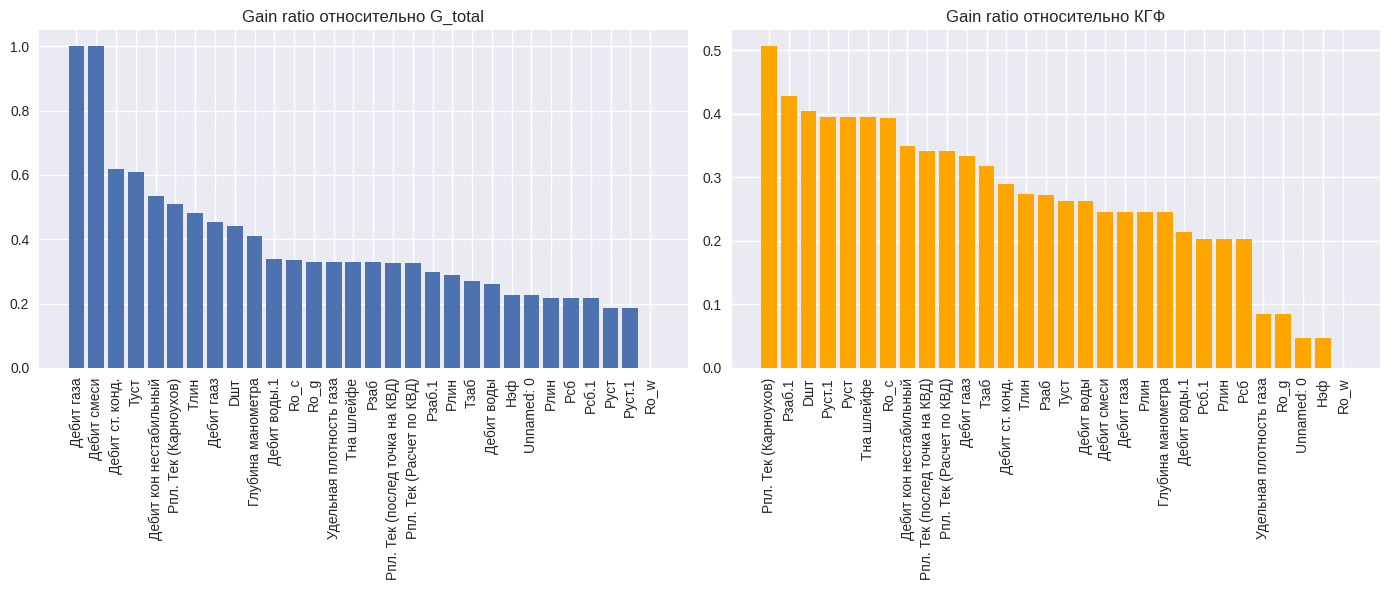

In [ ]:
y_G_total_disc = make_discrete_for_gain_ratio(df[TARGET_G_TOTAL])
y_KGF_disc = make_discrete_for_gain_ratio(df[TARGET_KGF])

gain_G = {}
gain_K = {}

for col in feature_names:
    x_num = pd.to_numeric(df[col], errors="coerce").values

    # Если после приведения всё NaN или меньше 2 ненулевых значений — пропускаем
    mask = ~np.isnan(x_num)
    if mask.sum() < 2:
        continue

    x_disc = discretize_into_bins(x_num, n_bins=4)

    gain_G[col] = gain_ratio(x_disc, y_G_total_disc)
    gain_K[col] = gain_ratio(x_disc, y_KGF_disc)

gain_G_series = pd.Series(gain_G).sort_values(ascending=False)
gain_K_series = pd.Series(gain_K).sort_values(ascending=False)

print("gain_G_series:\n", gain_G_series.head(20))
print("\ngain_K_series:\n", gain_K_series.head(20))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(range(len(gain_G_series)), gain_G_series.values)
axes[0].set_xticks(range(len(gain_G_series)))
axes[0].set_xticklabels(gain_G_series.index, rotation=90)
axes[0].set_title("Gain ratio относительно G_total")

axes[1].bar(range(len(gain_K_series)), gain_K_series.values, color="orange")
axes[1].set_xticks(range(len(gain_K_series)))
axes[1].set_xticklabels(gain_K_series.index, rotation=90)
axes[1].set_title("Gain ratio относительно КГФ")

plt.tight_layout()
plt.show()

### Комментарий к гистограммам gain_ratio

- Для `G_total` максимальное значение gain_ratio наблюдается у дебитных характеристик (`Дебит газа`, `Дебит смеси`, `Дебит ст. конд.`) и температур/геометрии (`Туст`, `Tлин`, `Глубина манометра`, `Dшт`), что согласуется с физическим смыслом целевой переменной.
- Для `КГФ` наибольший gain_ratio дают разные оценки пластового давления (`Рпл. Тек (Карноухов)`, `Рпл. Тек (послед точка на КВД)`, `Рпл. Тек (Расчет по КВД)`), забойные и устьевые давления (`Рзаб`, `Рзаб.1`, `Руст`, `Руст.1`), а также плотности и дебиты.
- Признаки, у которых gain_ratio близок к нулю по обеим целевым переменным и одновременно отсутствует заметная корреляция с целями, считаются **слабо влияющими** на целевые переменные и рассматриваются как кандидаты на удаление.
- Совместный анализ gain_ratio и корреляций позволяет отделить **действительно информативные физические параметры** от служебных и дублирующих признаков.

## Анализ признаков, выбросов и пропусков

### 1. Пропуски и служебные/пустые признаки

- **Полностью пустые столбцы**: `Unnamed: 1`, `КГФ.1` имеют `count = 0` и удаляются из дальнейшего анализа как не содержащие информации.
- **Идентификатор**: `Unnamed: 0` отражает только номер/ID объекта, имеет большую дисперсию, но не несёт физического смысла для модели → используется только как идентификатор, **не включается в набор признаков**.
- У остальных признаков число наблюдений близко к максимальному (22–23 из 24), поэтому пропуски считаются умеренными и на этапе расчёта корреляций и gain_ratio обрабатываются через игнорирование пар с NaN.

### 2. Константные и почти константные признаки

- **`Ro_w`**: стандартное отклонение равно 0, все значения = 1000 → признак константный, **исключается**.
- Частично константные признаки (`Тзаб`, `Ro_c`, `Удельная плотность газа`, `Ro_g`) имеют небольшой разброс, но показывают ненулевой gain_ratio и/или заметную корреляцию с целями, поэтому **оставляются**.

### 3. Мультиколлинеарность и дубли

По матрице корреляций и описательной статистике видно группы признаков с очень высокими взаимными корреляциями (|r| ≈ 1):

- `Руст` и `Руст.1`
- `Рзаб` и `Рзаб.1`
- `Pсб` и `Pсб.1`
- `Дебит воды` и `Дебит воды.1`
- несколько вариантов дебитов (`Дебит газа`, `Дебит смеси`, `Дебит ст. конд.`, `Дебит гааз`) и разных оценок пластового давления (`Рпл. Тек (...)`).

С точки зрения построения модели такие сильно коррелирующие признаки избыточны. В каждой группе **оставляется по одному представителю** (более интерпретируемому/стандартному с точки зрения физики процесса), остальные помечаются как **кандидаты на удаление из-за мультиколлинеарности**.

### 4. Важность признаков по gain_ratio

- Для целевой переменной **`G_total`** наибольший gain_ratio показывают признаки: `Дебит газа`, `Дебит смеси`, `Дебит ст. конд.`, `Туст`, `Дебит кон нестабильный`, `Рпл. Тек (Карноухов)`, `Tлин`, `Дебит гааз`, `Dшт`, `Глубина манометра`, а также плотности (`Ro_c`, `Ro_g`, `Удельная плотность газа`) и некоторые давления/температуры.
- Для целевой переменной **`КГФ`** наибольший gain_ratio имеют: `Рпл. Тек (Карноухов)`, `Рзаб.1`, `Dшт`, `Руст`/`Руст.1`, `Тна шлейфе`, `Ro_c`, `Дебит кон нестабильный`, `Рпл. Тек (послед точка на КВД)` и `Рпл. Тек (Расчет по КВД)`, а также дебиты (`Дебит гааз`, `Дебит ст. конд.`, `Дебит смеси`, `Дебит газа`) и давления (`Рзаб`, `Pлин`).
- Признаки с **низким gain_ratio одновременно по обеим целям** и без заметной корреляции с целями считаются **слабо информативными** и попадают в кандидаты на удаление.

### 5. Выбросы

- По гистограммам видно, что распределения дебитов (`Дебит газа`, `Дебит смеси`, `Дебит ст. конд.`, `Дебит гааз`, `Дебит кон нестабильный`) сильно правосторонне скошены: есть наблюдения значительно выше `Q3 + 1.5·IQR`. Эти значения интерпретируются как **высокодебитные режимы**, а не явные ошибки измерений, поэтому **строки с такими значениями не удаляются**.
- Для признаков с узким диапазоном (например, `Тзаб`, `Ro_w`) выбросов практически нет.
- На данном этапе (до построения модели) выбросы **не трогаются**; для последующего моделирования можно рассмотреть мягкую усечку (winsorization) или использование робастных методов, что будет обосновано отдельно.

### 6. Стратегия заполнения пропусков (на будущее)

- В рамках текущей лабораторной работы пропуски обрабатываются за счёт того, что при расчёте корреляций и gain_ratio используются только пары наблюдений без NaN.
- Для последующего построения моделей разумной стратегией является **заполнение медианой** по признаку (или медианой по группам скважин/режимов), так как медиана устойчива к выбросам и мало искажает распределение при небольшом числе пропусков.

### 7. Итоговый список признаков

- **Удаляем / не используем как признаки:**
  - `Unnamed: 1`, `КГФ.1` (полностью пустые);
  - `Unnamed: 0` (ID объекта);
  - `Ro_w` (константный признак);
  - дублирующиеся признаки из сильно коррелирующих пар (`Руст.1`, `Рзаб.1`, `Pсб.1`, одна из версий `Дебит воды`, лишние варианты дебитов и пластового давления) — для снижения мультиколлинеарности.
- **Оставляем в признаковом пространстве:**
  - давления (`Руст`, `Рзаб`, `Pлин`, `Pсб`), температуры (`Туст`, `Тна шлейфе`, `Тзаб`, `Tлин`), дебиты (`Дебит газа`, `Дебит смеси`, `Дебит ст. конд.`, `Дебит гааз`, `Дебит кон нестабильный`, одна из версий `Дебит воды`), геометрические параметры (`Глубина манометра`, `Dшт`), оценки пластового давления (`Рпл. Тек (...)`) и плотности (`Ro_g`, `Ro_c`, `Удельная плотность газа`).

Такое решение опирается на комбинацию описательной статистики, матрицы корреляций и gain_ratio по двум целевым переменным и соответствует рекомендациям по отбору признаков из лекции.